# Klasifikasi Lahan Sawah dan Non-Sawah Menggunakan Citra Sentinel-2A dan Random Forest

Notebook ini mendokumentasikan proses klasifikasi lahan sawah dan non-sawah yang saya kerjakan. Sampel berupa polygon yang saya digitasi di QGIS, disimpan sebagai dua layer terpisah (Sawah dan Non-Sawah), masing-masing 50 polygon. Citra Sentinel-2A diunduh lewat openEO, lalu dilanjutkan dengan ekstraksi nilai piksel, pelatihan model Random Forest, evaluasi akurasi, dan pembuatan peta hasil klasifikasi.

**Alur pengerjaan:**
1. Membaca polygon sampel dan membersihkan geometri yang kosong
2. Menyamakan jumlah sampel menjadi 50 polygon per kelas
3. Mengunduh citra Sentinel-2A (sudah terpotong sesuai area sampel) lewat openEO
4. Mengambil nilai piksel di dalam polygon, lalu menghitung NDVI dan NDWI
5. Membagi data latih dan data uji per polygon, lalu melatih Random Forest
6. Mengevaluasi akurasi, mengklasifikasi seluruh citra, menghitung luas, dan menyimpan hasil

**Persiapan:** dua file sampel, yaitu `sawah.zip` dan `non-sawah.zip` (masing-masing berisi `.shp`, `.shx`, `.dbf`, `.prj`), harus berada di folder yang sama dengan notebook ini (di Google Colab, upload lewat panel File). Pengunduhan citra memerlukan akun Copernicus Data Space.

## 1. Instalasi library

Pada langkah ini saya memasang library yang dibutuhkan: `geopandas` untuk membaca shapefile, `openeo` untuk mengunduh citra Sentinel-2, `rasterio` untuk membaca dan menulis raster, `scikit-learn` untuk Random Forest dan evaluasi, serta `matplotlib` dan `seaborn` untuk grafik dan peta. Cell ini cukup dijalankan sekali.

In [1]:
%pip install -q geopandas openeo rasterio scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.0 MB/s eta 0:00:00


## 2. Import library

Seluruh library yang dipakai saya panggil sekali di awal, sehingga cell-cell berikutnya bisa langsung memakainya.

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import openeo
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    cohen_kappa_score, ConfusionMatrixDisplay,
)

## 3. Membaca dan membersihkan data sampel

Pada langkah ini saya membaca dua layer sampel yang tersimpan terpisah, yaitu `sawah.zip` dan `non-sawah.zip`, lalu menggabungkannya menjadi satu GeoDataFrame. Label kelas saya beri otomatis dari nama file, sehingga tidak bergantung pada kolom atribut apa pun: Sawah diberi `target = 1` dan Non-Sawah diberi `target = 0`.

Pembersihan yang saya lakukan pada tiap layer:

- **Membuang geometri kosong.** Feature yang geometrinya NULL punya baris atribut tetapi tidak punya bentuk polygon, sehingga tidak bisa dipakai untuk mengambil nilai piksel.
- **Memperbaiki geometri yang tidak valid** dengan `buffer(0)` (jika ada).
- **Mengubah CRS ke EPSG:4326** agar kedua layer seragam.

Saya juga menghitung luas tiap polygon (dalam m², memakai proyeksi UTM 49S) karena nanti dipakai pada pemilihan sampel, dan memberi `poly_id` unik untuk tiap polygon agar pembagian data latih dan uji bisa dilakukan per polygon.

In [9]:
SAWAH_FILE = "sawah.shp"            # boleh juga "sawah.shp"
NONSAWAH_FILE = "non-sawah.shp"     # boleh juga "non-sawah.shp"


def baca_bersih(path, kelas, target):
    g = gpd.read_file(path)
    awal = len(g)

    # 1) buang geometri kosong
    g = g[~(g.geometry.isna() | g.geometry.is_empty)].copy()

    # 2) perbaiki geometri tidak valid (kalau ada)
    tidak_valid = ~g.geometry.is_valid
    if tidak_valid.any():
        g.loc[tidak_valid, "geometry"] = g.loc[tidak_valid, "geometry"].buffer(0)

    # 3) seragamkan CRS; atribut asli tidak dipakai, cukup geometrinya
    g = g.to_crs("EPSG:4326")[["geometry"]].copy()
    g["kelas"] = kelas
    g["target"] = target
    print(f"{kelas:<10}: {awal} feature awal -> {len(g)} polygon valid")
    return g


gdf_sawah = baca_bersih(SAWAH_FILE, "Sawah", 1)
gdf_non = baca_bersih(NONSAWAH_FILE, "Non-Sawah", 0)

gdf = gpd.GeoDataFrame(
    pd.concat([gdf_sawah, gdf_non], ignore_index=True), crs="EPSG:4326"
)
gdf["luas_m2"] = gdf.to_crs("EPSG:32749").area
gdf["poly_id"] = gdf.index

print("\nJumlah polygon valid:", len(gdf))
print(gdf["kelas"].value_counts())
print(f"Total luas sampel   : {gdf['luas_m2'].sum() / 1e4:.2f} ha")

Sawah     : 52 feature awal -> 50 polygon valid
Non-Sawah : 55 feature awal -> 53 polygon valid

Jumlah polygon valid: 103
kelas
Non-Sawah    53
Sawah        50
Name: count, dtype: int64
Total luas sampel   : 9.57 ha


## 4. Menyamakan jumlah sampel per kelas

Agar kedua kelas seimbang, saya memakai tepat **50 polygon per kelas** (`N_PER_KELAS = 50`). Aturannya:

- Jika polygon valid pada suatu kelas **lebih dari 50**, saya mengambil 50 polygon **terbesar**. Polygon yang lebih besar mencakup lebih banyak piksel Sentinel-2 (10 × 10 m) dan lebih sedikit piksel campuran di tepinya, sehingga nilai spektralnya lebih mewakili jenis lahannya.
- Jika **kurang dari 50**, seluruh polygon yang ada dipakai dan akan muncul peringatan.

Pemilihan dilakukan setelah polygon kosong dibuang, jadi polygon yang kosong tidak ikut terhitung.

In [10]:
N_PER_KELAS = 50

bagian = []
for kelas, g in gdf.groupby("kelas"):
    if len(g) > N_PER_KELAS:
        g = g.nlargest(N_PER_KELAS, "luas_m2")          # ambil yang terbesar
    elif len(g) < N_PER_KELAS:
        print(f"Peringatan: polygon {kelas} hanya {len(g)} (< {N_PER_KELAS}), semuanya dipakai.")
    bagian.append(g)

gdf = gpd.GeoDataFrame(pd.concat(bagian), crs=gdf.crs).sort_index().reset_index(drop=True)
gdf["poly_id"] = gdf.index

print("Jumlah polygon yang dipakai:")
print(gdf["kelas"].value_counts())
print("\nLuas median polygon (m2):")
print(gdf.groupby("kelas")["luas_m2"].median().round(0))

Jumlah polygon yang dipakai:
kelas
Sawah        50
Non-Sawah    50
Name: count, dtype: int64

Luas median polygon (m2):
kelas
Non-Sawah     244.0
Sawah        1534.0
Name: luas_m2, dtype: float64


## 5. Menentukan area unduhan (bounding box)

openEO membutuhkan batas area dalam derajat (barat, selatan, timur, utara). Batas ini saya ambil dari seluruh polygon sampel, lalu saya tambah margin 0,003 derajat (sekitar 300 m) agar polygon di tepi tidak terpotong dan peta hasil punya sedikit ruang di sekelilingnya. Karena area studi kecil, file citra yang diunduh juga kecil.

In [11]:
minx, miny, maxx, maxy = gdf.total_bounds
buffer_deg = 0.003

bbox = {
    "west":  float(minx - buffer_deg),
    "south": float(miny - buffer_deg),
    "east":  float(maxx + buffer_deg),
    "north": float(maxy + buffer_deg),
}
print("Bounding box:", bbox)

Bounding box: {'west': 112.8953501, 'south': -7.1842893000000005, 'east': 112.9139656, 'north': -7.1683546}


## 6. Mengunduh citra Sentinel-2A lewat openEO

Pada langkah ini saya terhubung ke Copernicus Data Space dan login lewat browser. Citra yang diambil:

- Koleksi `SENTINEL2_L2A` (reflektan permukaan) dengan band **B02** (biru), **B03** (hijau), **B04** (merah), **B08** (NIR), dan **B11** (SWIR).
- Tutupan awan maksimum 10%, dengan rentang waktu 1 Mei sampai 30 September 2026.
- Dari seluruh tanggal yang tersedia saya ambil nilai **median**, sehingga piksel yang tertutup awan pada satu tanggal digantikan oleh tanggal lain.

Hasilnya diunduh sebagai satu file GeoTIFF bernama `sentinel2_sawah.tif`. Proses berjalan di server openEO, sehingga bisa memakan waktu beberapa menit.

In [12]:
conn = openeo.connect("openeo.dataspace.copernicus.eu")
conn.authenticate_oidc()

cube = conn.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=bbox,
    temporal_extent=["2026-05-01", "2026-09-30"],
    bands=["B02", "B03", "B04", "B08", "B11"],
    max_cloud_cover=10,
)
cube = cube.median_time()

TIF = "sentinel2_sawah.tif"
print("Mengunduh citra...")
cube.download(TIF, format="GTiff")
print("Selesai:", TIF)

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=RRNY-FVIS 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.
Mengunduh citra...
Selesai: sentinel2_sawah.tif


## 7. Membaca citra dan memeriksa posisi polygon

Citra saya baca menjadi array NumPy berbentuk `(5 band, tinggi, lebar)`, sambil menyimpan informasi georeferensinya (CRS, transform, ukuran piksel). Polygon sampel kemudian dikonversi ke CRS citra dan ditampilkan di atas komposit warna asli (R = B04, G = B03, B = B02): **hijau untuk Sawah dan merah untuk Non-Sawah**. Tampilan ini saya gunakan sebagai pemeriksaan visual bahwa polygon berada di lokasi yang benar.

Ukuran citra : (5, 178, 208) | CRS: EPSG:32749 | resolusi: (10.0, 10.0)


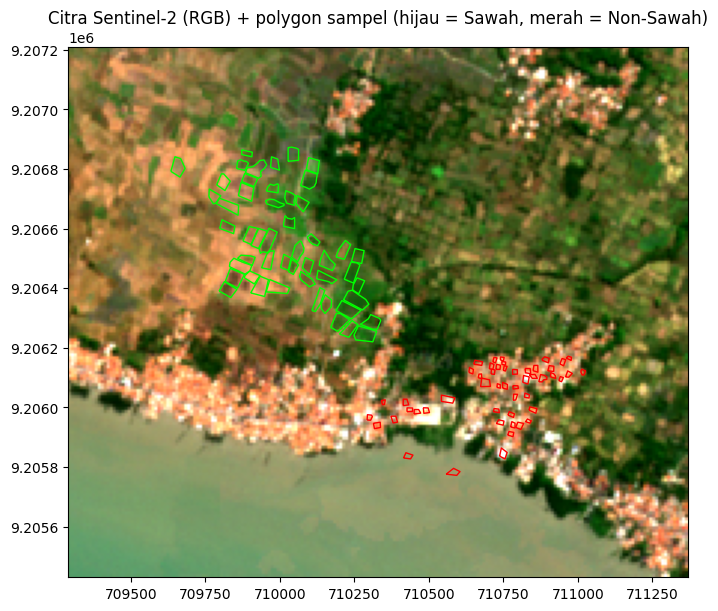

In [13]:
with rasterio.open(TIF) as src:
    img = src.read().astype("float32")      # (5, h, w)
    crs = src.crs
    transform = src.transform
    bounds = src.bounds
    profile = src.profile
    res = src.res

h, w = img.shape[1:]
print("Ukuran citra :", img.shape, "| CRS:", crs, "| resolusi:", res)

gdf_utm = gdf.to_crs(crs)

# komposit warna asli dengan peregangan kontras 2-98%
rgb = np.stack([img[2], img[1], img[0]], axis=-1)
lo, hi = np.nanpercentile(rgb, (2, 98))
rgb = np.clip((rgb - lo) / (hi - lo), 0, 1)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
gdf_utm[gdf_utm.target == 1].boundary.plot(ax=ax, color="lime", linewidth=1)
gdf_utm[gdf_utm.target == 0].boundary.plot(ax=ax, color="red", linewidth=1)
ax.set_title("Citra Sentinel-2 (RGB) + polygon sampel (hijau = Sawah, merah = Non-Sawah)")
plt.show()

## 8. Mengambil nilai piksel di dalam polygon

Polygon sampel saya berukuran kecil (median sekitar 430 m², atau sekitar 4 piksel Sentinel-2 yang masing-masing 10 × 10 m). Karena itu saya mengambil **semua piksel di dalam polygon**, bukan hanya satu piksel di titik tengahnya, sehingga data latih jauh lebih banyak.

Untuk setiap polygon, saya membuat mask piksel yang masuk ke dalamnya. Jika polygon lebih kecil dari satu piksel dan mask-nya kosong, saya memakai `all_touched=True` agar piksel yang tersentuh polygon tetap diambil. Nilai kelima band dikumpulkan bersama `poly_id` dan labelnya.

In [14]:
band_names = ["B02", "B03", "B04", "B08", "B11"]
rows = []

for _, r in gdf_utm.iterrows():
    m = geometry_mask([r.geometry], out_shape=(h, w), transform=transform, invert=True)
    if m.sum() == 0:                       # polygon lebih kecil dari satu piksel
        m = geometry_mask([r.geometry], out_shape=(h, w), transform=transform,
                          invert=True, all_touched=True)
    d = pd.DataFrame(img[:, m].T, columns=band_names)
    d["poly_id"] = r.poly_id
    d["target"] = r.target
    d["kelas"] = r.kelas
    rows.append(d)

df = pd.concat(rows, ignore_index=True)
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=band_names)

print("Total piksel sampel:", len(df))
print(df["kelas"].value_counts())
print("Polygon yang punya piksel:", df["poly_id"].nunique(), "dari", len(gdf))

Total piksel sampel: 963
kelas
Sawah        816
Non-Sawah    147
Name: count, dtype: int64
Polygon yang punya piksel: 100 dari 100


## 9. Menghitung indeks NDVI dan NDWI

Selain kelima band, saya menambahkan dua indeks sebagai fitur:

- **NDVI** = (B08 − B04) / (B08 + B04), bernilai tinggi pada vegetasi hijau sehingga membantu mengenali padi yang sedang tumbuh.
- **NDWI** = (B03 − B08) / (B03 + B08), bernilai tinggi pada air atau genangan sehingga membantu mengenali sawah yang tergenang.

Angka kecil `1e-6` pada penyebut mencegah pembagian dengan nol. Dengan begitu, total fitur yang dipakai ada 7. Tabel di bawah menunjukkan rata-rata tiap fitur per kelas.

In [15]:
df["NDVI"] = (df["B08"] - df["B04"]) / (df["B08"] + df["B04"] + 1e-6)
df["NDWI"] = (df["B03"] - df["B08"]) / (df["B03"] + df["B08"] + 1e-6)

fitur = ["B02", "B03", "B04", "B08", "B11", "NDVI", "NDWI"]

# ringkasan rata-rata nilai tiap fitur per kelas
df.groupby("kelas")[fitur].mean().round(3)

,B02,B03,B04,B08,B11,NDVI,NDWI
kelas,,,,,,,
Non-Sawah,946.007019,1192.286011,1598.965942,2360.897949,2924.020020,0.185,-0.319
Sawah,648.479980,950.804016,986.638000,3151.110107,2747.043945,0.529,-0.536


## 10. Membagi data latih dan data uji (per polygon)

Pembagian saya lakukan pada **polygon**, bukan pada piksel. Piksel yang bertetangga dalam satu polygon nilainya sangat mirip, sehingga jika satu polygon terbagi ke data latih dan data uji sekaligus, model seolah-olah melihat jawabannya dan akurasi menjadi terlalu optimis.

Sebanyak 80% polygon menjadi data latih dan 20% menjadi data uji, dengan proporsi Sawah dan Non-Sawah dijaga sama (`stratify`). Semua piksel dari polygon latih masuk ke `train_df`, dan semua piksel dari polygon uji masuk ke `test_df`.

In [16]:
poly = df.groupby("poly_id")["target"].first().reset_index()

train_poly, test_poly = train_test_split(
    poly, test_size=0.2, stratify=poly["target"], random_state=42
)

train_df = df[df["poly_id"].isin(train_poly["poly_id"])]
test_df = df[df["poly_id"].isin(test_poly["poly_id"])]

X_train, y_train = train_df[fitur], train_df["target"]
X_test, y_test = test_df[fitur], test_df["target"]

print(f"Polygon latih: {len(train_poly)} | polygon uji: {len(test_poly)}")
print(f"Piksel latih : {len(train_df)} | piksel uji : {len(test_df)}")

Polygon latih: 80 | polygon uji: 20
Piksel latih : 752 | piksel uji : 211


## 11. Melatih model Random Forest

Saya memakai Random Forest, yaitu kumpulan banyak pohon keputusan yang hasil akhirnya diambil lewat voting. Algoritma ini tahan terhadap data yang tidak terlalu rapi dan tidak memerlukan normalisasi fitur. Parameter yang saya atur:

- `n_estimators=200`: jumlah pohon.
- `class_weight="balanced"`: jumlah piksel kedua kelas tidak sama (polygon sawah umumnya lebih besar), sehingga kelas yang lebih sedikit diberi bobot lebih besar agar tidak diabaikan model.
- `random_state=42`: agar hasilnya dapat diulang.

In [17]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
print("Model selesai dilatih.")

Model selesai dilatih.


## 12. Evaluasi pada data uji

Model memprediksi piksel dari polygon uji, yang tidak pernah dilihat saat pelatihan, lalu hasilnya dibandingkan dengan label sebenarnya. Metrik yang saya tampilkan:

- **Overall accuracy**: persentase piksel yang diprediksi benar.
- **Kappa**: akurasi yang sudah dikoreksi terhadap kemungkinan tebakan acak; semakin mendekati 1 semakin baik.
- **Classification report**: precision dan recall untuk tiap kelas. *Recall* sama dengan producer's accuracy, dan *precision* sama dengan user's accuracy.
- **Confusion matrix**: tabel jumlah prediksi benar dan salah per kelas.

Overall accuracy : 99.05%
Kappa            : 0.953

              precision    recall  f1-score   support

   Non-Sawah       1.00      0.92      0.96        25
       Sawah       0.99      1.00      0.99       186

    accuracy                           0.99       211
   macro avg       0.99      0.96      0.98       211
weighted avg       0.99      0.99      0.99       211



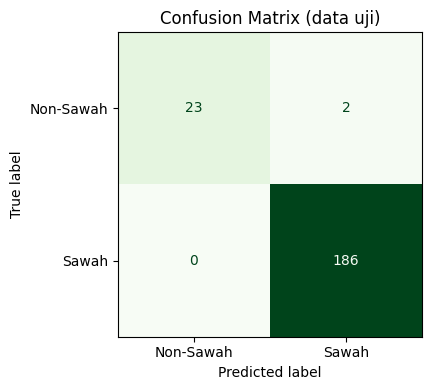

In [18]:
y_pred = model.predict(X_test)

print(f"Overall accuracy : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Kappa            : {cohen_kappa_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, target_names=["Non-Sawah", "Sawah"]))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Non-Sawah", "Sawah"],
    cmap="Greens", colorbar=False, ax=ax,
)
ax.set_title("Confusion Matrix (data uji)")
plt.tight_layout()
plt.show()

## 13. Validasi silang (cross-validation) per polygon

Jumlah polygon uji hanya sekitar 20, sehingga hasil dari satu kali pembagian bisa kebetulan terlalu bagus atau terlalu buruk. Untuk itu saya menjalankan validasi silang 5 lipatan, yaitu menguji model 5 kali dengan pembagian berbeda lalu merata-ratakan hasilnya.

Saya memakai `StratifiedGroupKFold` agar semua piksel dari satu polygon selalu berada di sisi yang sama (latih atau uji), sesuai prinsip pada langkah 10. Rata-rata dan simpangan baku dari lima lipatan ini lebih dapat dipercaya sebagai ukuran kinerja model dibandingkan satu angka akurasi.

In [19]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
skor = []

for i, (tr, te) in enumerate(sgkf.split(df[fitur], df["target"], groups=df["poly_id"]), 1):
    m = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                               random_state=42, n_jobs=-1)
    m.fit(df.iloc[tr][fitur], df.iloc[tr]["target"])
    acc = accuracy_score(df.iloc[te]["target"], m.predict(df.iloc[te][fitur]))
    skor.append(acc)
    print(f"Lipatan {i}: akurasi = {acc * 100:.2f}%")

print(f"\nRata-rata: {np.mean(skor) * 100:.2f}%  (± {np.std(skor) * 100:.2f}%)")

Lipatan 1: akurasi = 95.07%
Lipatan 2: akurasi = 97.85%
Lipatan 3: akurasi = 97.13%
Lipatan 4: akurasi = 100.00%
Lipatan 5: akurasi = 98.53%

Rata-rata: 97.72%  (± 1.63%)


## 14. Kepentingan fitur (feature importance)

Grafik berikut menunjukkan fitur yang paling banyak digunakan model untuk membedakan sawah dan non-sawah. Dari sini saya bisa melihat apakah indeks air (NDWI), indeks vegetasi (NDVI), atau band tertentu yang paling menentukan.

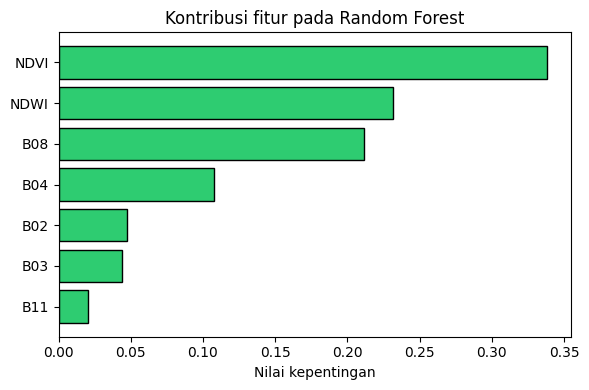

In [20]:
imp = pd.Series(model.feature_importances_, index=fitur).sort_values()

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(imp.index, imp.values, color="#2ecc71", edgecolor="black")
ax.set_xlabel("Nilai kepentingan")
ax.set_title("Kontribusi fitur pada Random Forest")
plt.tight_layout()
plt.show()

## 15. Mengklasifikasi seluruh citra

Model yang sudah dilatih saya gunakan untuk memprediksi **setiap piksel** pada citra, bukan hanya piksel di dalam polygon sampel. NDVI dan NDWI dihitung untuk seluruh citra, lalu ditumpuk dengan kelima band menjadi 7 lapisan fitur. Piksel yang bernilai kosong (NaN) dilewati dan diberi nilai 255 sebagai penanda "tidak ada data".

Hasil prediksi dimasukkan ke DataFrame berkolom nama fitur agar sesuai dengan data latih (ini juga menghindari peringatan *"X does not have valid feature names"*). Terakhir, luas tiap kelas dihitung dari jumlah piksel dikali luas satu piksel.

In [21]:
b = img.astype("float64")
ndvi_map = (b[3] - b[2]) / (b[3] + b[2] + 1e-6)
ndwi_map = (b[1] - b[3]) / (b[1] + b[3] + 1e-6)

stack = np.stack([b[0], b[1], b[2], b[3], b[4], ndvi_map, ndwi_map], axis=-1)
valid = np.isfinite(stack).all(axis=-1)

pred = np.full((h, w), 255, dtype="uint8")          # 255 = tidak ada data
X_all = pd.DataFrame(stack[valid], columns=fitur)
pred[valid] = model.predict(X_all).astype("uint8")

luas_piksel_ha = (res[0] * res[1]) / 1e4
n_sawah = int((pred == 1).sum())
n_non = int((pred == 0).sum())
print(f"Sawah     : {n_sawah:>7,} piksel = {n_sawah * luas_piksel_ha:,.1f} ha")
print(f"Non-Sawah : {n_non:>7,} piksel = {n_non * luas_piksel_ha:,.1f} ha")
print(f"Persentase sawah: {100 * n_sawah / (n_sawah + n_non):.1f}%")

Sawah     :  24,533 piksel = 245.3 ha
Non-Sawah :  12,491 piksel = 124.9 ha
Persentase sawah: 66.3%


## 16. Menampilkan peta hasil dan menyimpannya

Hasil klasifikasi saya tampilkan sebagai peta dengan warna hijau untuk Sawah dan merah untuk Non-Sawah, lengkap dengan legenda dan koordinat. Garis putih tipis menunjukkan polygon sampel, sehingga terlihat seberapa cocok hasil klasifikasi dengan sampelnya.

Hasil kemudian saya simpan dalam dua format: `peta_klasifikasi_rf.png` (gambar peta untuk laporan, resolusi 300 dpi) dan `hasil_klasifikasi_rf.tif` (GeoTIFF satu band dengan nilai 1 = Sawah, 0 = Non-Sawah, 255 = tidak ada data) yang bisa dibuka kembali di QGIS.

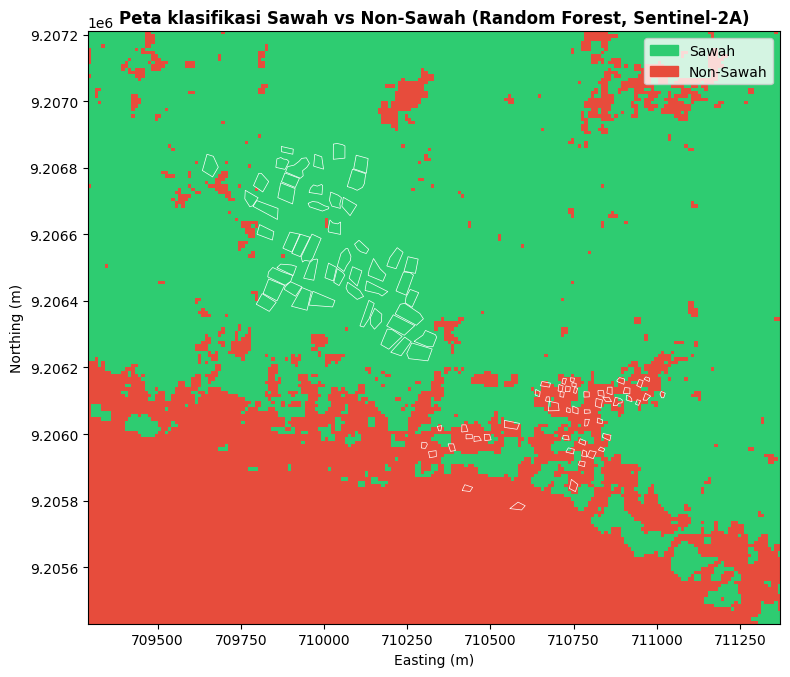

Tersimpan: peta_klasifikasi_rf.png dan hasil_klasifikasi_rf.tif


In [22]:
peta = np.ma.masked_equal(pred, 255)
cmap = mcolors.ListedColormap(["#e74c3c", "#2ecc71"])    # 0 = merah, 1 = hijau

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(peta, cmap=cmap, vmin=0, vmax=1,
          extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
gdf_utm.boundary.plot(ax=ax, color="white", linewidth=0.5)
ax.legend(handles=[
    mpatches.Patch(color="#2ecc71", label="Sawah"),
    mpatches.Patch(color="#e74c3c", label="Non-Sawah"),
], loc="upper right")
ax.set_title("Peta klasifikasi Sawah vs Non-Sawah (Random Forest, Sentinel-2A)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig("peta_klasifikasi_rf.png", dpi=300)
plt.show()

# simpan sebagai GeoTIFF
profile.update(count=1, dtype="uint8", nodata=255, compress="lzw")
with rasterio.open("hasil_klasifikasi_rf.tif", "w", **profile) as dst:
    dst.write(pred, 1)
print("Tersimpan: peta_klasifikasi_rf.png dan hasil_klasifikasi_rf.tif")

## Catatan dan keterbatasan

- Data uji dipisah per polygon, sehingga akurasinya lebih jujur dibandingkan pemisahan per piksel. Namun jumlah polygon uji hanya sekitar 20, jadi angka akurasi dapat berubah cukup banyak jika `random_state` diganti. Karena itu hasil validasi silang pada langkah 13 saya laporkan bersama hasil data uji.
- Komposit median Mei sampai September dapat mencampur fase tanam yang berbeda (tergenang, vegetatif, panen). Jika hasilnya kurang baik, rentang waktu (`temporal_extent`) dapat dipersempit ke bulan yang paling sesuai dengan kondisi saat sampel dibuat.
- Citra tidak melalui masking awan berbasis SCL, hanya filter tutupan awan dan komposit median. Sisa awan atau bayangan awan masih dapat menjadi sumber kesalahan.
- Sampel non-sawah cenderung beragam (permukiman, kebun, badan air, lahan kosong). Jika recall kelas Non-Sawah lebih rendah, hal itu wajar dan perlu dibahas.
- Jumlah sampel dibuat seimbang 50 polygon per kelas. Polygon yang geometrinya kosong dibuang sebelum pemilihan, dan jika polygon valid melebihi 50, saya mengambil 50 polygon terbesar.
- Polygon Non-Sawah umumnya lebih kecil daripada polygon Sawah, sehingga jumlah piksel Non-Sawah jauh lebih sedikit. Ketidakseimbangan ini sudah saya imbangi dengan class_weight='balanced', tetapi tetap perlu diperhatikan saat membaca recall kelas Non-Sawah.